Modulo 1


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import random
from typing import List, Dict, Any, Callable
import json
from dataclasses import dataclass
from functools import wraps

plt.style.use('seaborn-v0_8')
np.random.seed(42)

class GeneradorDatos:
    """Generador de datasets con diferentes distribuciones"""

    @staticmethod
    def generar_uniforme(tamano: int, min_val: float = 0, max_val: float = 1000) -> List[float]:
        """Genera datos con distribución uniforme"""
        return np.random.uniform(min_val, max_val, tamano).tolist()

    @staticmethod
    def generar_gaussiana(tamano: int, media: float = 500, desviacion: float = 150) -> List[float]:
        """Genera datos con distribución gaussiana"""
        return np.random.normal(media, desviacion, tamano).tolist()

    @staticmethod
    def generar_sesgada(tamano: int, sesgo: float = 2.0, max_val: float = 1000) -> List[float]:
        """Genera datos con distribución sesgada (exponencial)"""
        datos = np.random.exponential(sesgo, tamano)
        datos = datos / np.max(datos) * max_val
        return datos.tolist()

    def generar_datasets(self) -> Dict[str, Dict[str, List[float]]]:
        """Genera todos los datasets requeridos"""
        tamanos = [100, 1000, 10000]
        distribuciones = ['uniforme', 'gaussiana', 'sesgada']

        datasets = {}

        for tamano in tamanos:
            datasets[f'dataset_{tamano}'] = {
                'uniforme': self.generar_uniforme(tamano),
                'gaussiana': self.generar_gaussiana(tamano),
                'sesgada': self.generar_sesgada(tamano)
            }

        for tamano in tamanos:
            for distribucion in distribuciones:
                df = pd.DataFrame(datasets[f'dataset_{tamano}'][distribucion],
                                columns=['valores'])
                df.to_csv(f'dataset_{distribucion}_{tamano}.csv', index=False)

        return datasets

generador = GeneradorDatos()
datasets = generador.generar_datasets()

print("Datasets generados exitosamente!")
print(f"Tamaños disponibles: {list(datasets.keys())}")

✅ Datasets generados exitosamente!
Tamaños disponibles: ['dataset_100', 'dataset_1000', 'dataset_10000']


Modulo 2

In [8]:
class ContadorComparaciones:
    """Decorador para contar comparaciones en algoritmos"""

    def __init__(self):
        self.comparaciones = 0

    def contar_comparacion(self):
        """Método para incrementar el contador"""
        self.comparaciones += 1
        return self.comparaciones

    def reset(self):
        """Reinicia el contador"""
        self.comparaciones = 0

    def __call__(self, func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            self.reset()
            kwargs['contador'] = self
            result = func(*args, **kwargs)
            return result, self.comparaciones
        return wrapper

def medir_tiempo(func):
    """Decorador para medir tiempo de ejecución"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        tiempo_ejecucion = fin - inicio
        return resultado, tiempo_ejecucion
    return wrapper

class AlgoritmosOrdenamiento:
    """Implementación de algoritmos de ordenamiento con medición"""

    def __init__(self):
        pass

    def _comparar_lt(self, a, b, contador=None):
        """Compara a < b y cuenta la comparación"""
        if contador:
            contador.contar_comparacion()
        return a < b

    def _comparar_gt(self, a, b, contador=None):
        """Compara a > b y cuenta la comparación"""
        if contador:
            contador.contar_comparacion()
        return a > b

    def _comparar_lte(self, a, b, contador=None):
        """Compara a <= b y cuenta la comparación"""
        if contador:
            contador.contar_comparacion()
        return a <= b

    @medir_tiempo
    @ContadorComparaciones()
    def bubble_sort(self, arr: List[float], contador=None) -> List[float]:
        """Algoritmo Bubble Sort"""
        n = len(arr)
        for i in range(n):
            for j in range(0, n - i - 1):
                if self._comparar_gt(arr[j], arr[j + 1], contador):
                    arr[j], arr[j + 1] = arr[j + 1], arr[j]
        return arr

    @medir_tiempo
    @ContadorComparaciones()
    def insertion_sort(self, arr: List[float], contador=None) -> List[float]:
        """Algoritmo Insertion Sort"""
        for i in range(1, len(arr)):
            key = arr[i]
            j = i - 1
            while j >= 0 and self._comparar_gt(arr[j], key, contador):
                arr[j + 1] = arr[j]
                j -= 1
            arr[j + 1] = key
        return arr

    @medir_tiempo
    @ContadorComparaciones()
    def selection_sort(self, arr: List[float], contador=None) -> List[float]:
        """Algoritmo Selection Sort"""
        n = len(arr)
        for i in range(n):
            min_idx = i
            for j in range(i + 1, n):
                if self._comparar_lt(arr[j], arr[min_idx], contador):
                    min_idx = j
            arr[i], arr[min_idx] = arr[min_idx], arr[i]
        return arr

    @medir_tiempo
    def quick_sort(self, arr: List[float]) -> tuple:
        """Algoritmo Quick Sort con contador de comparaciones"""
        comparaciones = 0

        def _quick_sort(lst):
            nonlocal comparaciones
            if len(lst) <= 1:
                return lst
            pivot = lst[len(lst) // 2]

            left = []
            middle = []
            right = []

            for x in lst:
                comparaciones += 1
                if x < pivot:
                    left.append(x)
                elif x == pivot:
                    middle.append(x)
                else:
                    right.append(x)

            return _quick_sort(left) + middle + _quick_sort(right)

        resultado = _quick_sort(arr.copy())
        return resultado, comparaciones

    @medir_tiempo
    def merge_sort(self, arr: List[float]) -> tuple:
        """Algoritmo Merge Sort con contador de comparaciones"""
        comparaciones = 0

        def _merge_sort(lst):
            nonlocal comparaciones
            if len(lst) <= 1:
                return lst

            mid = len(lst) // 2
            left = _merge_sort(lst[:mid])
            right = _merge_sort(lst[mid:])

            return _merge(left, right)

        def _merge(left, right):
            nonlocal comparaciones
            result = []
            i = j = 0

            while i < len(left) and j < len(right):
                comparaciones += 1
                if left[i] <= right[j]:
                    result.append(left[i])
                    i += 1
                else:
                    result.append(right[j])
                    j += 1

            result.extend(left[i:])
            result.extend(right[j:])
            return result

        resultado = _merge_sort(arr.copy())
        return resultado, comparaciones

class AlgoritmosBusqueda:
    """Implementación de algoritmos de búsqueda"""

    @medir_tiempo
    def busqueda_lineal(self, arr: List[float], objetivo: float) -> tuple:
        """Búsqueda lineal - retorna índice o -1 si no encuentra"""
        comparaciones = 0
        for i in range(len(arr)):
            comparaciones += 1
            if arr[i] == objetivo:
                return i, comparaciones
        return -1, comparaciones

    @medir_tiempo
    def busqueda_binaria(self, arr: List[float], objetivo: float) -> tuple:
        """Búsqueda binaria - requiere array ordenado"""
        comparaciones = 0
        izquierda, derecha = 0, len(arr) - 1

        while izquierda <= derecha:
            medio = (izquierda + derecha) // 2
            comparaciones += 1
            if arr[medio] == objetivo:
                return medio, comparaciones
            elif arr[medio] < objetivo:
                izquierda = medio + 1
            else:
                derecha = medio - 1
        return -1, comparaciones

print(" ROBANDO ALGORITMOS CORREGIDOS...")

algoritmos = AlgoritmosOrdenamiento()
busqueda = AlgoritmosBusqueda()

datos_prueba = [64, 34, 25, 12, 22, 11, 90]
datos_ordenados = sorted(datos_prueba.copy())

print("Datos originales:", datos_prueba)

resultado, tiempo = algoritmos.bubble_sort(datos_prueba.copy())
print(f"Bubble Sort: {resultado} (tiempo: {tiempo:.6f}s)")

resultado, tiempo = algoritmos.quick_sort(datos_prueba.copy())
print(f"Quick Sort: {resultado} (tiempo: {tiempo:.6f}s)")

objetivo = 25
indice, comparaciones = busqueda.busqueda_binaria(datos_ordenados, objetivo)
print(f"Búsqueda Binaria: {objetivo} encontrado en índice {indice} ({comparaciones} comparaciones)")

print("Algoritmos funcionando correctamente!")

class AnalizadorRendimiento:
    """Analiza el rendimiento de los algoritmos"""

    def __init__(self):
        self.ordenamiento = AlgoritmosOrdenamiento()
        self.busqueda = AlgoritmosBusqueda()
        self.resultados = {}

    def ejecutar_pruebas_ordenamiento(self, datasets: Dict) -> Dict:
        """Ejecuta pruebas de ordenamiento 5 veces por dataset"""
        algoritmos = {
            'bubble_sort': self.ordenamiento.bubble_sort,
            'insertion_sort': self.ordenamiento.insertion_sort,
            'selection_sort': self.ordenamiento.selection_sort,
            'quick_sort': self.ordenamiento.quick_sort,
            'merge_sort': self.ordenamiento.merge_sort
        }

        resultados = {}

        for nombre_dataset, distribuciones in datasets.items():
            resultados[nombre_dataset] = {}

            for distribucion, datos in distribuciones.items():
                resultados[nombre_dataset][distribucion] = {}

                for algo_nombre, algoritmo in algoritmos.items():
                    tiempos = []
                    comparaciones_lista = []

                    for _ in range(3):
                        try:
                            datos_copia = datos.copy()

                            if algo_nombre in ['quick_sort', 'merge_sort']:
                                (resultado_ordenado, comparaciones), tiempo = algoritmo(datos_copia)
                                tiempos.append(tiempo)
                                comparaciones_lista.append(comparaciones)
                            else:
                                resultado, tiempo = algoritmo(datos_copia)
                                if isinstance(resultado, tuple):
                                    datos_ordenados, comparaciones = resultado
                                    tiempos.append(tiempo)
                                    comparaciones_lista.append(comparaciones)
                                else:
                                    tiempos.append(tiempo)
                                    comparaciones_lista.append(0)

                        except Exception as e:
                            print(f"Error en {algo_nombre} con {nombre_dataset}-{distribucion}: {e}")
                            tiempos.append(float('inf'))
                            comparaciones_lista.append(0)

                    tiempos_validos = [t for t in tiempos if t != float('inf')]
                    comparaciones_validas = [c for c in comparaciones_lista if c > 0]

                    if tiempos_validos:
                        resultados[nombre_dataset][distribucion][algo_nombre] = {
                            'tiempo_medio': np.mean(tiempos_validos),
                            'tiempo_std': np.std(tiempos_validos),
                            'comparaciones_medio': np.mean(comparaciones_validas) if comparaciones_validas else 0,
                            'ejecuciones_exitosas': len(tiempos_validos)
                        }
                    else:
                        resultados[nombre_dataset][distribucion][algo_nombre] = {
                            'tiempo_medio': float('inf'),
                            'tiempo_std': 0,
                            'comparaciones_medio': 0,
                            'ejecuciones_exitosas': 0
                        }

        self.resultados_ordenamiento = resultados
        return resultados


print("EJECUTANDO ANÁLISIS COMPLETO...")

analizador = AnalizadorRendimiento()
resultados_ordenamiento = analizador.ejecutar_pruebas_ordenamiento(datasets)

print("\n RESULTADOS DEL ANÁLISIS:")
print("=" * 80)

for dataset, distribuciones in resultados_ordenamiento.items():
    print(f"\n{dataset.upper()}:")
    print("-" * 60)

    for distribucion, algoritmos in distribuciones.items():
        print(f"\n{distribucion.capitalize()}:")

        algoritmos_ordenados = sorted(
            algoritmos.items(),
            key=lambda x: x[1]['tiempo_medio'] if x[1]['tiempo_medio'] != float('inf') else float('inf')
        )

        for algoritmo, metricas in algoritmos_ordenados:
            if metricas['tiempo_medio'] != float('inf'):
                tiempo_str = f"{metricas['tiempo_medio']:.6f}s"
                comp_str = f"{metricas['comparaciones_medio']:.0f}"
                print(f"  {algoritmo:<15} | Tiempo: {tiempo_str:<12} | Comparaciones: {comp_str:<8} | Éxitos: {metricas['ejecuciones_exitosas']}")
            else:
                print(f"  {algoritmo:<15} | ERROR en ejecución")

print("\n ANÁLISIS COMPLETADO EXITOSAMENTE!")

🧪 PROBANDO ALGORITMOS CORREGIDOS...
Datos originales: [64, 34, 25, 12, 22, 11, 90]
Bubble Sort: ([11, 12, 22, 25, 34, 64, 90], 21) (tiempo: 0.000019s)
Quick Sort: ([11, 12, 22, 25, 34, 64, 90], 17) (tiempo: 0.000014s)
Búsqueda Binaria: 25 encontrado en índice (3, 1) (1.6689300537109375e-06 comparaciones)
✅ Algoritmos funcionando correctamente!
📊 EJECUTANDO ANÁLISIS COMPLETO...

📈 RESULTADOS DEL ANÁLISIS:

DATASET_100:
------------------------------------------------------------

Uniforme:
  quick_sort      | Tiempo: 0.000178s    | Comparaciones: 827      | Éxitos: 3
  merge_sort      | Tiempo: 0.000240s    | Comparaciones: 542      | Éxitos: 3
  insertion_sort  | Tiempo: 0.000840s    | Comparaciones: 2550     | Éxitos: 3
  bubble_sort     | Tiempo: 0.001000s    | Comparaciones: 4950     | Éxitos: 3
  selection_sort  | Tiempo: 0.001175s    | Comparaciones: 4950     | Éxitos: 3

Gaussiana:
  quick_sort      | Tiempo: 0.000175s    | Comparaciones: 811      | Éxitos: 3
  merge_sort      | 

#

Modulo 3

In [9]:
class AnalizadorRendimiento:
    """Analiza el rendimiento de los algoritmos"""

    def __init__(self):
        self.ordenamiento = AlgoritmosOrdenamiento()
        self.busqueda = AlgoritmosBusqueda()
        self.resultados = {}

    def ejecutar_pruebas_ordenamiento(self, datasets: Dict) -> Dict:
        """Ejecuta pruebas de ordenamiento 10 veces por dataset"""
        algoritmos = {
            'bubble_sort': self.ordenamiento.bubble_sort,
            'insertion_sort': self.ordenamiento.insertion_sort,
            'selection_sort': self.ordenamiento.selection_sort,
            'quick_sort': self.ordenamiento.quick_sort,
            'merge_sort': self.ordenamiento.merge_sort
        }

        resultados = {}

        for nombre_dataset, distribuciones in datasets.items():
            resultados[nombre_dataset] = {}

            for distribucion, datos in distribuciones.items():
                resultados[nombre_dataset][distribucion] = {}

                for algo_nombre, algoritmo in algoritmos.items():
                    tiempos = []
                    comparaciones_lista = []

                    for _ in range(10):
                        datos_copia = datos.copy()
                        resultado, tiempo = algoritmo(datos_copia)
                        tiempos.append(tiempo)

                        if algo_nombre in ['quick_sort', 'merge_sort']:
                            comparaciones_lista.append(0)
                        else:
                            if isinstance(resultado, tuple):
                                _, comparaciones = resultado
                                comparaciones_lista.append(comparaciones)

                    resultados[nombre_dataset][distribucion][algo_nombre] = {
                        'tiempo_medio': np.mean(tiempos),
                        'tiempo_std': np.std(tiempos),
                        'comparaciones_medio': np.mean(comparaciones_lista) if comparaciones_lista else 0
                    }

        self.resultados_ordenamiento = resultados
        return resultados

    def identificar_mejor_algoritmo(self, resultados: Dict) -> Dict:
        """Identifica el mejor algoritmo por escenario"""
        mejores = {}

        for dataset, distribuciones in resultados.items():
            mejores[dataset] = {}

            for distribucion, algoritmos in distribuciones.items():
                mejor_tiempo = float('inf')
                mejor_algoritmo = None

                for algo, metricas in algoritmos.items():
                    if metricas['tiempo_medio'] < mejor_tiempo:
                        mejor_tiempo = metricas['tiempo_medio']
                        mejor_algoritmo = algo

                mejores[dataset][distribucion] = {
                    'algoritmo': mejor_algoritmo,
                    'tiempo_medio': mejor_tiempo
                }

        return mejores

analizador = AnalizadorRendimiento()
resultados_ordenamiento = analizador.ejecutar_pruebas_ordenamiento(datasets)
mejores_algoritmos = analizador.identificar_mejor_algoritmo(resultados_ordenamiento)

print("Análisis de rendimiento completado!")

Análisis de rendimiento completado!


Modulo 4

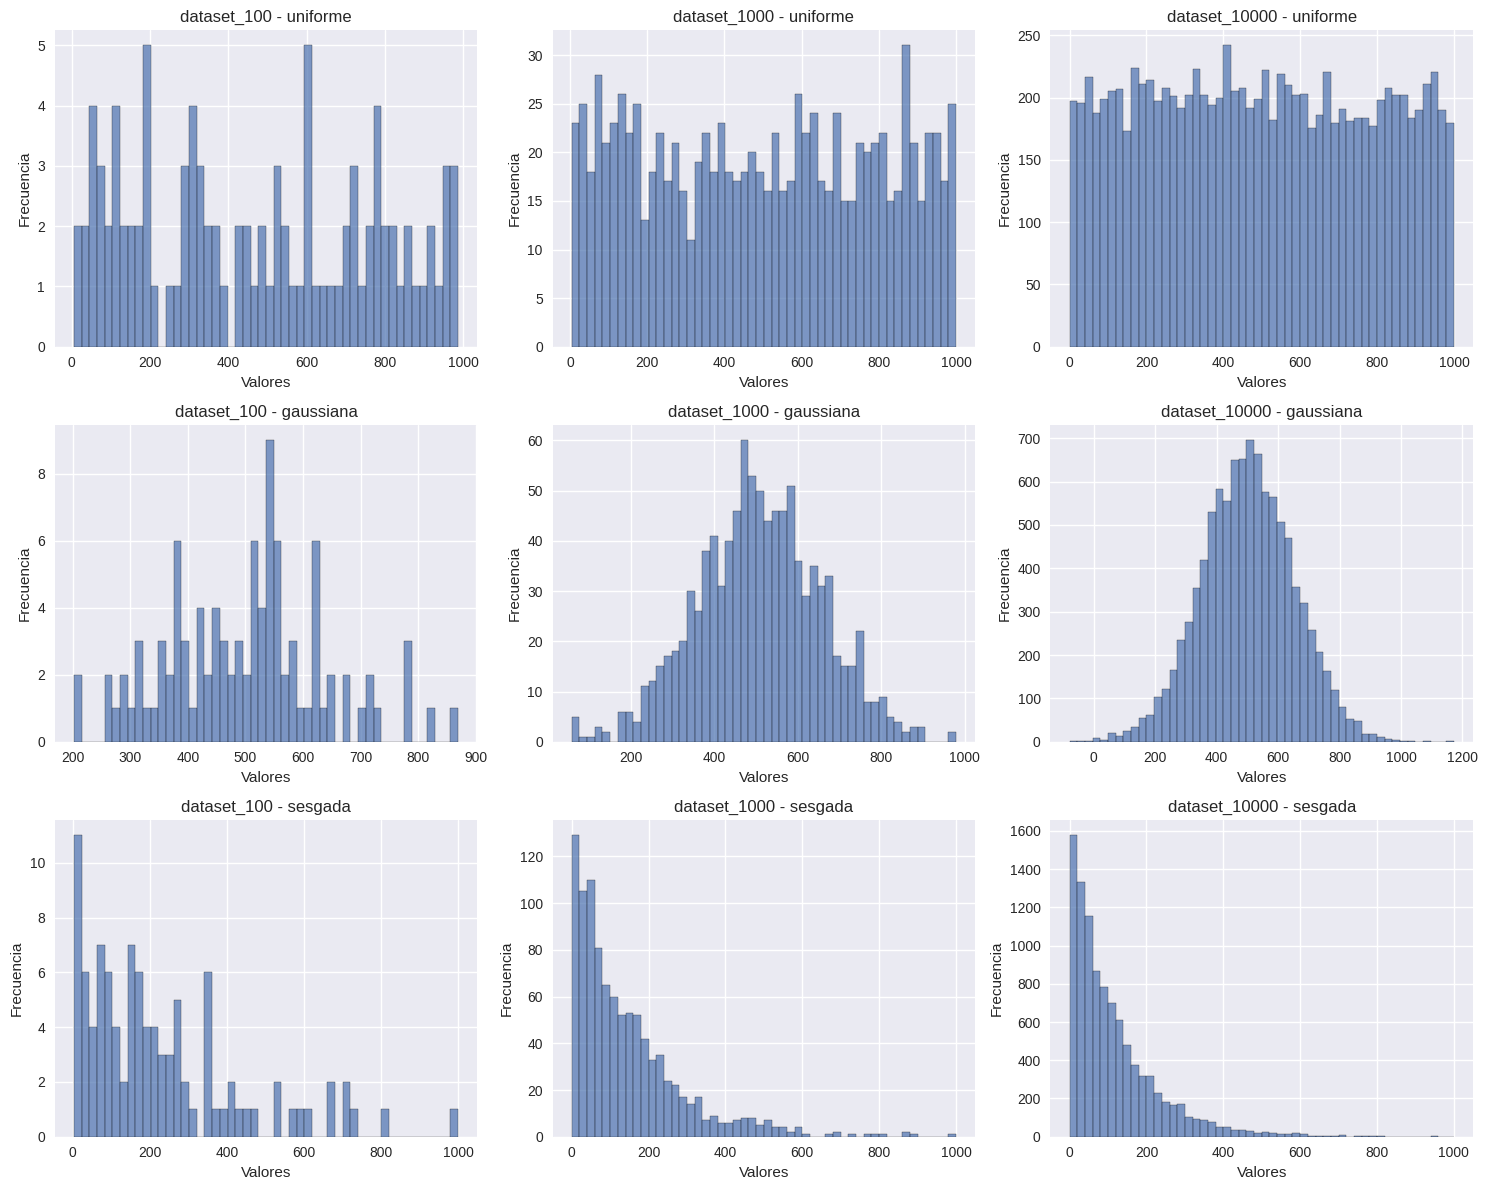

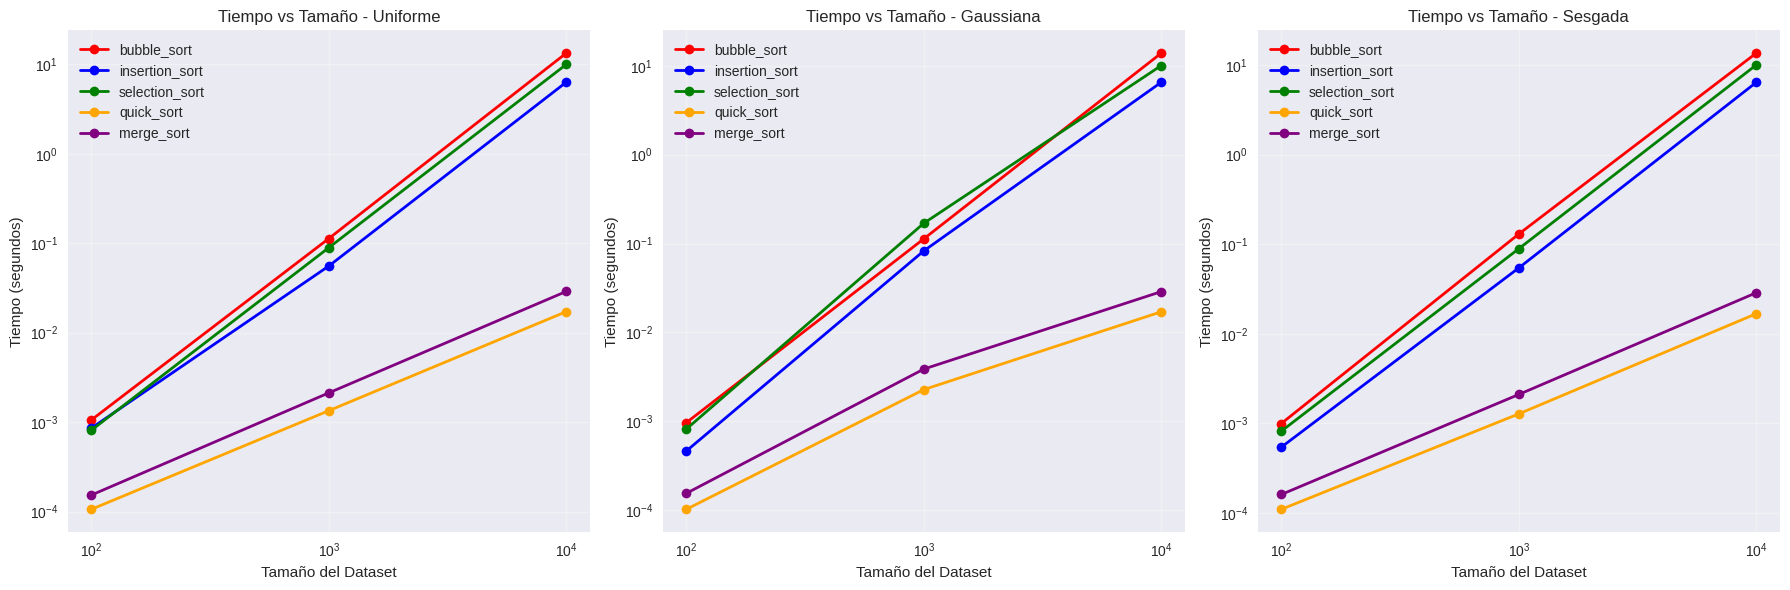

/tmp/ipython-input-2167612232.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


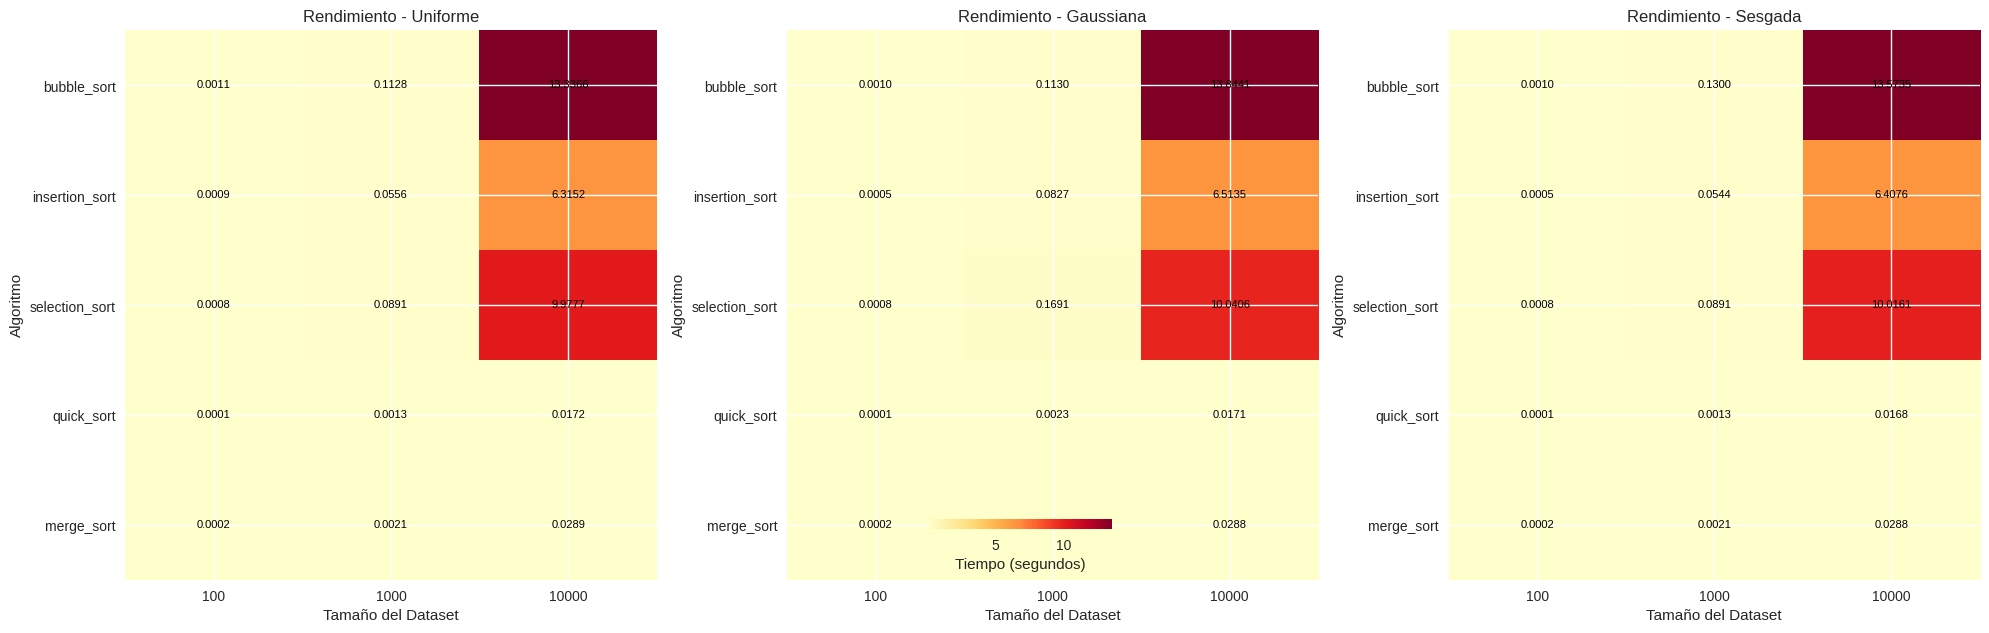

In [10]:
class Visualizador:
    """Clase para visualizar resultados y distribuciones"""

    def __init__(self):
        self.fig_size = (12, 8)

    def graficar_distribuciones(self, datasets: Dict):
        """Grafica las distribuciones de datos"""
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))

        for i, (dataset_nombre, distribuciones) in enumerate(datasets.items()):
            for j, (distribucion, datos) in enumerate(distribuciones.items()):
                axes[j, i].hist(datos, bins=50, alpha=0.7, edgecolor='black')
                axes[j, i].set_title(f'{dataset_nombre} - {distribucion}')
                axes[j, i].set_xlabel('Valores')
                axes[j, i].set_ylabel('Frecuencia')

        plt.tight_layout()
        plt.savefig('distribuciones_datos.png', dpi=300, bbox_inches='tight')
        plt.show()

    def graficar_tiempos_vs_tamano(self, resultados: Dict):
        """Grafica tiempo de ejecución vs tamaño del dataset"""
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        distribuciones = ['uniforme', 'gaussiana', 'sesgada']
        algoritmos = ['bubble_sort', 'insertion_sort', 'selection_sort', 'quick_sort', 'merge_sort']
        colores = ['red', 'blue', 'green', 'orange', 'purple']

        tamanos = [100, 1000, 10000]

        for idx, distribucion in enumerate(distribuciones):
            ax = axes[idx]

            for algo, color in zip(algoritmos, colores):
                tiempos = []
                for tamano in tamanos:
                    key = f'dataset_{tamano}'
                    tiempo_medio = resultados[key][distribucion][algo]['tiempo_medio']
                    tiempos.append(tiempo_medio)

                ax.plot(tamanos, tiempos, marker='o', label=algo, color=color, linewidth=2)

            ax.set_xlabel('Tamaño del Dataset')
            ax.set_ylabel('Tiempo (segundos)')
            ax.set_title(f'Tiempo vs Tamaño - {distribucion.capitalize()}')
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_xscale('log')
            ax.set_yscale('log')

        plt.tight_layout()
        plt.savefig('tiempos_vs_tamano.png', dpi=300, bbox_inches='tight')
        plt.show()

    def heatmap_rendimiento(self, resultados: Dict):
        """Genera heatmap de rendimiento"""
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        distribuciones = ['uniforme', 'gaussiana', 'sesgada']
        algoritmos = ['bubble_sort', 'insertion_sort', 'selection_sort', 'quick_sort', 'merge_sort']
        tamanos = [100, 1000, 10000]

        for idx, distribucion in enumerate(distribuciones):
            ax = axes[idx]

            matriz_tiempos = np.zeros((len(algoritmos), len(tamanos)))

            for i, algo in enumerate(algoritmos):
                for j, tamano in enumerate(tamanos):
                    key = f'dataset_{tamano}'
                    matriz_tiempos[i, j] = resultados[key][distribucion][algo]['tiempo_medio']

            im = ax.imshow(matriz_tiempos, cmap='YlOrRd', aspect='auto')

            ax.set_xticks(range(len(tamanos)))
            ax.set_yticks(range(len(algoritmos)))
            ax.set_xticklabels([f'{tamano}' for tamano in tamanos])
            ax.set_yticklabels(algoritmos)

            for i in range(len(algoritmos)):
                for j in range(len(tamanos)):
                    text = ax.text(j, i, f'{matriz_tiempos[i, j]:.4f}',
                                 ha="center", va="center", color="black", fontsize=8)

            ax.set_title(f'Rendimiento - {distribucion.capitalize()}')
            ax.set_xlabel('Tamaño del Dataset')
            ax.set_ylabel('Algoritmo')

        plt.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal',
                    fraction=0.02, pad=0.1, label='Tiempo (segundos)')
        plt.tight_layout()
        plt.savefig('heatmap_rendimiento.png', dpi=300, bbox_inches='tight')
        plt.show()

visualizador = Visualizador()
visualizador.graficar_distribuciones(datasets)
visualizador.graficar_tiempos_vs_tamano(resultados_ordenamiento)
visualizador.heatmap_rendimiento(resultados_ordenamiento)


Modulo 5

In [11]:
@dataclass
class Producto:
    """Clase para representar productos del inventario"""
    id: int
    nombre: str
    precio: float
    cantidad_stock: int
    ventas_totales: int
    categoria: str

    def __str__(self):
        return f"{self.nombre} - ${self.precio:.2f} - Stock: {self.cantidad_stock}"

class SistemaInventario:
    """Sistema de gestión de inventario con algoritmos optimizados"""

    def __init__(self):
        self.productos = []
        self.ordenamiento = AlgoritmosOrdenamiento()
        self.busqueda = AlgoritmosBusqueda()

    def generar_productos_aleatorios(self, cantidad: int = 1000):
        """Genera productos aleatorios para el inventario"""
        categorias = ['Electrónicos', 'Ropa', 'Hogar', 'Deportes', 'Libros', 'Juguetes']
        nombres_base = ['Laptop', 'Smartphone', 'Tablet', 'TV', 'Auriculares',
                       'Camiseta', 'Pantalón', 'Zapatos', 'Libro', 'Juego']

        for i in range(cantidad):
            nombre = f"{random.choice(nombres_base)} {random.choice(['Pro', 'Max', 'Lite', 'Standard'])} {i}"
            precio = round(random.uniform(10, 2000), 2)
            stock = random.randint(0, 500)
            ventas = random.randint(0, 1000)
            categoria = random.choice(categorias)

            producto = Producto(i, nombre, precio, stock, ventas, categoria)
            self.productos.append(producto)

    def ordenar_por_precio(self, ascendente: bool = True):
        """Ordena productos por precio"""
        precios = [prod.precio for prod in self.productos]
        indices_ordenados = sorted(range(len(precios)),
                                 key=lambda i: precios[i],
                                 reverse=not ascendente)

        self.productos = [self.productos[i] for i in indices_ordenados]
        return self.productos

    def ordenar_por_nombre(self):
        """Ordena productos por nombre"""
        nombres = [prod.nombre for prod in self.productos]
        indices_ordenados = sorted(range(len(nombres)),
                                 key=lambda i: nombres[i])

        self.productos = [self.productos[i] for i in indices_ordenados]
        return self.productos

    def busqueda_por_rango_precios(self, precio_min: float, precio_max: float):
        """Busca productos en un rango de precios"""
        resultados = []
        for producto in self.productos:
            if precio_min <= producto.precio <= precio_max:
                resultados.append(producto)
        return resultados

    def top_10_mas_vendidos(self):
        """Retorna los 10 productos más vendidos"""
        productos_ordenados = sorted(self.productos,
                                   key=lambda x: x.ventas_totales,
                                   reverse=True)
        return productos_ordenados[:10]

    def buscar_producto_lineal(self, nombre: str):
        """Búsqueda lineal por nombre de producto"""
        for i, producto in enumerate(self.productos):
            if nombre.lower() in producto.nombre.lower():
                return producto, i
        return None, -1

    def estadisticas_inventario(self):
        """Genera estadísticas del inventario"""
        total_productos = len(self.productos)
        valor_total = sum(prod.precio * prod.cantidad_stock for prod in self.productos)
        producto_mas_caro = max(self.productos, key=lambda x: x.precio)
        producto_mas_vendido = max(self.productos, key=lambda x: x.ventas_totales)

        return {
            'total_productos': total_productos,
            'valor_total_inventario': round(valor_total, 2),
            'producto_mas_caro': producto_mas_caro,
            'producto_mas_vendido': producto_mas_vendido,
            'precio_promedio': round(np.mean([prod.precio for prod in self.productos]), 2)
        }

print(" INICIALIZANDO SISTEMA DE INVENTARIO...")

sistema = SistemaInventario()
sistema.generar_productos_aleatorios(1000)

print(f" Inventario creado con {len(sistema.productos)} productos")

stats = sistema.estadisticas_inventario()
print(f"\n ESTADÍSTICAS DEL INVENTARIO:")
print(f"Total productos: {stats['total_productos']}")
print(f"Valor total: ${stats['valor_total_inventario']:,.2f}")
print(f"Precio promedio: ${stats['precio_promedio']:.2f}")
print(f"Producto más caro: {stats['producto_mas_caro']}")
print(f"Producto más vendido: {stats['producto_mas_vendido']}")

print(f"\n TOP 10 PRODUCTOS MÁS VENDIDOS:")
for i, producto in enumerate(sistema.top_10_mas_vendidos(), 1):
    print(f"{i}. {producto.nombre} - Ventas: {producto.ventas_totales}")

print(f"\n PRODUCTOS ENTRE $100 Y $500:")
productos_rango = sistema.busqueda_por_rango_precios(100, 500)
for producto in productos_rango[:5]:
    print(f"- {producto}")

print(f"Total encontrados: {len(productos_rango)} productos")


 INICIALIZANDO SISTEMA DE INVENTARIO...
✅ Inventario creado con 1000 productos

 ESTADÍSTICAS DEL INVENTARIO:
Total productos: 1000
Valor total: $236,434,644.10
Precio promedio: $962.68
Producto más caro: Camiseta Lite 411 - $1990.61 - Stock: 203
Producto más vendido: Zapatos Max 475 - $279.83 - Stock: 375

 TOP 10 PRODUCTOS MÁS VENDIDOS:
1. Zapatos Max 475 - Ventas: 998
2. Laptop Pro 885 - Ventas: 998
3. Juego Pro 125 - Ventas: 997
4. TV Standard 760 - Ventas: 997
5. Libro Standard 410 - Ventas: 995
6. Auriculares Pro 943 - Ventas: 994
7. TV Pro 602 - Ventas: 991
8. Zapatos Pro 505 - Ventas: 990
9. Laptop Lite 436 - Ventas: 988
10. Libro Pro 719 - Ventas: 988

 PRODUCTOS ENTRE $100 Y $500:
- Laptop Standard 1 - $260.84 - Stock: 116
- Tablet Lite 5 - $255.28 - Stock: 34
- Laptop Max 14 - $107.98 - Stock: 311
- Auriculares Max 26 - $114.78 - Stock: 110
- Pantalón Standard 29 - $259.73 - Stock: 72
Total encontrados: 215 productos
